In [1]:
# numpy handles pretty much anything that is a number/vector/matrix/array
import numpy as np
# pandas handles dataframes
import pandas as pd
# matplotlib emulates Matlabs plotting functionality
import matplotlib.pyplot as plt
# seaborn is another good plotting library. In particular, I like it for heatmaps (https://seaborn.pydata.org/generated/seaborn.heatmap.html)
import seaborn as sns;
# stats models is a package that is going to perform the regression analysis
from statsmodels import api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score
# os allows us to manipulate variables on out local machine, such as paths and environment variables
import os
# self explainatory, dates and times
from datetime import datetime, date
# a helper package to help us iterate over objects
import itertools

In [2]:
# load data
train = pd.read_csv('communities_train.csv')
val = pd.read_csv('communities_val.csv')
test = pd.read_csv('communities_test.csv')

# Pull out X and y components of the data
# if you want to convert this data to numpy format, you can add .to_numpy() to the end of each row below
X_train = train.iloc[:,0:-1]
y_train = train.iloc[:,-1]
X_val = val.iloc[:,0:-1]
y_val = val.iloc[:,-1]
X_test = test.iloc[:,0:-1]
y_test = test.iloc[:,-1]

In [3]:
# If you wish to pre-process the data, do so here. In your write-up, outline why you choose to do, or choose not to do, any
# pre-processing
# we need to add in a column of constants
X_train = sm.add_constant(X_train)
X_val = sm.add_constant(X_val)
X_test = sm.add_constant(X_test)

Model 1 RMSE = 0.15491210066258224
                              OLS Regression Results                             
Dep. Variable:      ViolentCrimesPerPop    R-squared:                       0.759
Model:                               OLS   Adj. R-squared:                  0.637
Method:                    Least Squares   F-statistic:                     6.207
Date:                   Sun, 15 Mar 2026   Prob (F-statistic):           7.72e-28
Time:                           09:42:19   Log-Likelihood:                 251.07
No. Observations:                    298   AIC:                            -300.1
Df Residuals:                        197   BIC:                             73.27
Df Model:                            100                                         
Covariance Type:               nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

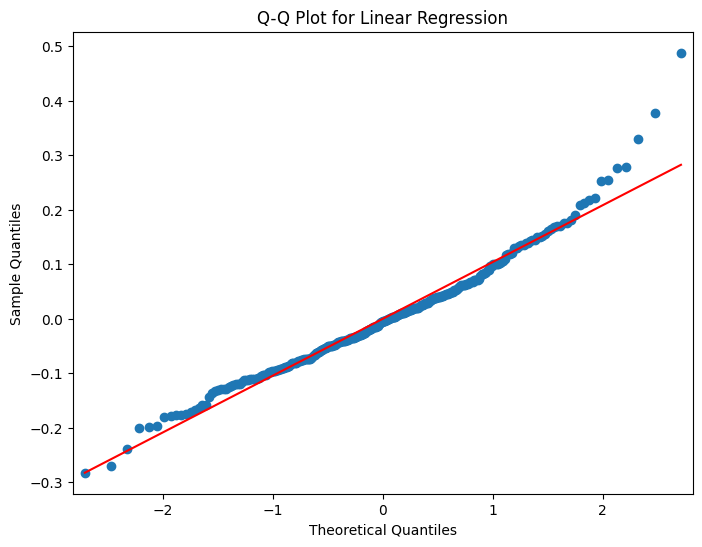

Text(0.5, 1.0, 'Residuals v Fitted')

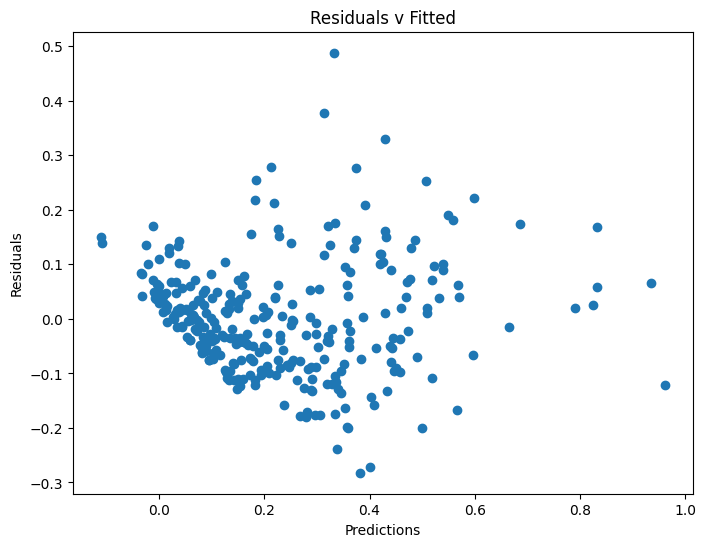

In [4]:
#Train a linear regression model to predict the number of violent crimes per captia from the socio-economic data
# train your Linear Regression model here. Data has already been split into predictors (X_train, X_val and X_test) and the
# desired response (y_train, y_val and y_test above).
#
# Note that you DO NOT NEED to remove any variables, or add higher order terms. JUST USE THE DATA AS IS.
#
model_1 = sm.OLS(y_train, X_train)
model_1_fit = model_1.fit()
pred_1 = model_1_fit.predict(X_val)
print('Model 1 RMSE = {}'.format(
  np.sqrt(mean_squared_error(y_val, model_1_fit.predict(X_val)))))
print(model_1_fit.summary())

print(model_1_fit.params)
fig, ax = plt.subplots(figsize=(8,6))
sm.qqplot(model_1_fit.resid, ax=ax, line='s')
plt.title('Q-Q Plot for Linear Regression')
plt.show()
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(model_1_fit.predict(X_train), model_1_fit.resid)
ax.set_xlabel('Predictions')
ax.set_ylabel('Residuals')
plt.title('Residuals v Fitted')
# Once you've trained the model, evaluate it. This would include:
#  - Measuring the accuracy of the model (i.e. RMSE or similar measures)
#  - Looking at the properties of the fitted model, for example the R^2, and if all terms are contributing to the model
#  - Considering the validity of the trained model. This could include assumptions about independent predictors, and the 
#    distribution of the residuals
# Your write-up should include your findings regarding the above.

Linearity: Linear model is appropriate
Independence: Residuals independent of each other
Constant Variance: Residuals have mean=0, constant variance
Normality: Residuals have a Normal distribution

The Q-Q Plot suggest heavy tailing towards extreme values whereas mainting normality at all other places. The lack of extreme tailing for both extremities give reasonable evidence to suggest that our model's residuals are normal.

The Residuals v Fitted Values plot shows a slight bowing effect, particularly around predictions of 0.0 to 0.4. This indicates that the model wasnt able to capture the non-linear relationship, hence, sugessting that a linear model might be a poor choice for this data set. The graph also shows clear Heteroscedasticity due to the fanning effect. The cluster pattern witnessed at lower values suggest that our model is more accurate at predicting lower values than it is at higher values

In [5]:
# train your regularised models (ridge and lasso). Here you will use the same data as you used in for the above regression model
#
# One key consideration with your regularised models is the selection of lambda (i.e. the strength of the regularisation). A suggested 
# starting point for finding your value of lambda is suggested below using numpy.logspace (see 
# https://numpy.org/doc/stable/reference/generated/numpy.logspace.html). The code below will give you 50 values starting at 10-10 and 
# finishing at 1, spread on a log scale. Just note that for plotting things that result from this, you may want to change the scale of 
# your x-axis to a log scale (see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xscale.html)
#
# Note that the below list of lambda is going to be fairly coarse. For the sake of speed, we suggest that you avoid evaluating a huge
# number of lambdas in one pass, but you can get a more precise estimate by refining your estimate over multiple passes (i.e. if your
# initial estimate if 0.1, you could run the search again now looking over a range of [0.01 .. 1.0] or similar). If you wish to do this,
# we suggest limiting yourself to 2-3 passes at most. You do not need to get the perfect value of lambda.
#
# remember that lambda is a keyword in python, so we're calling the array below alphas. 
#

def standardise(data):
  """ Standardise/Normalise data to have zero mean and unit variance

  Args:
    data (np.array):
      data we want to standardise (usually covariates)

    Returns:
      Standardised data, mean of data, standard deviation of data
  """
  mu = np.mean(data, axis=0)
  sigma = np.std(data, axis=0)
  scaled = (data - mu) / sigma
  return scaled, mu, sigma
# Deleting the constant column
X_train = np.delete(X_train, 0, 1)
X_val = np.delete(X_val, 0, 1)
X_test = np.delete(X_test, 0, 1)

X_train_std, mu_train_x, sigma_train_x = standardise(X_train)
Y_train_std, mu_train_y, sigma_train_y = standardise(y_train)

X_val_std = (X_val - mu_train_x)/sigma_train_x
Y_val_std = (y_val - mu_train_y)/sigma_train_y
X_test_std = (X_test - mu_train_x)/sigma_train_x
Y_test_std = (y_test - mu_train_y)/sigma_train_y


alphas = np.logspace(-10, 0)



print(X_train_std)
# Once you've found your ridge and lasso models, evaluate them, following the approach you've used for the linear method, and compare the
# three models.

[[-0.39143344 -0.80462417 -0.73212039 ...  0.99494954  1.24256397
  -0.38997285]
 [-0.39143344 -2.18232876 -0.65404851 ...  3.57520634 -0.4388677
  -0.38997285]
 [-0.39143344  0.34346299 -0.65404851 ...  0.38507066 -0.64392035
  -0.38997285]
 ...
 [-0.29636648 -0.23058059 -0.69308445 ...  0.05667434 -0.4388677
  -0.38997285]
 [-0.39143344 -0.68981546  0.24377814 ... -0.64703206 -0.64392035
  -0.38997285]
 [-0.48650041  1.03231528 -0.61501257 ... -0.55320454 -0.64392035
  -0.38997285]]


Best values on Validation Data set
Best Lambda (Alpha) = 0.059636233165946365
Best R Squared = 0.7186831092271636
Best Adjusted = 0.5758826570582112
Best RMSE (val) = 0.14247363543425026
Best RMSE (test) = 0.13156035817628808
Best coefficients on the normalised model
Best slope = [[ 0.00656031]
 [-0.08293042]
 [ 0.08723254]
 [-0.05382055]
 [ 0.00129022]
 [-0.17549014]
 [-0.06043312]
 [ 0.04427131]
 [ 0.06591966]
 [ 0.06053484]
 [ 0.00077571]
 [ 0.07466782]
 [ 0.05203569]
 [-0.05048243]
 [ 0.01461949]
 [-0.10643079]
 [ 0.06601146]
 [ 0.04727984]
 [-0.08581759]
 [ 0.02345044]
 [ 0.009088  ]
 [ 0.00696331]
 [-0.00197448]
 [-0.03523003]
 [ 0.08776853]
 [ 0.0060188 ]
 [ 0.05245799]
 [-0.02277517]
 [-0.11101737]
 [-0.04528168]
 [ 0.0318149 ]
 [ 0.03522953]
 [-0.09936835]
 [ 0.13219588]
 [-0.07793625]
 [-0.00951811]
 [ 0.01248512]
 [-0.02657641]
 [-0.01866887]
 [ 0.00844981]
 [-0.00569363]
 [-0.00976019]
 [ 0.06734951]
 [-0.09929953]
 [-0.11847433]
 [-0.07767462]
 [-0.01975279]
 [ 0.06123346]

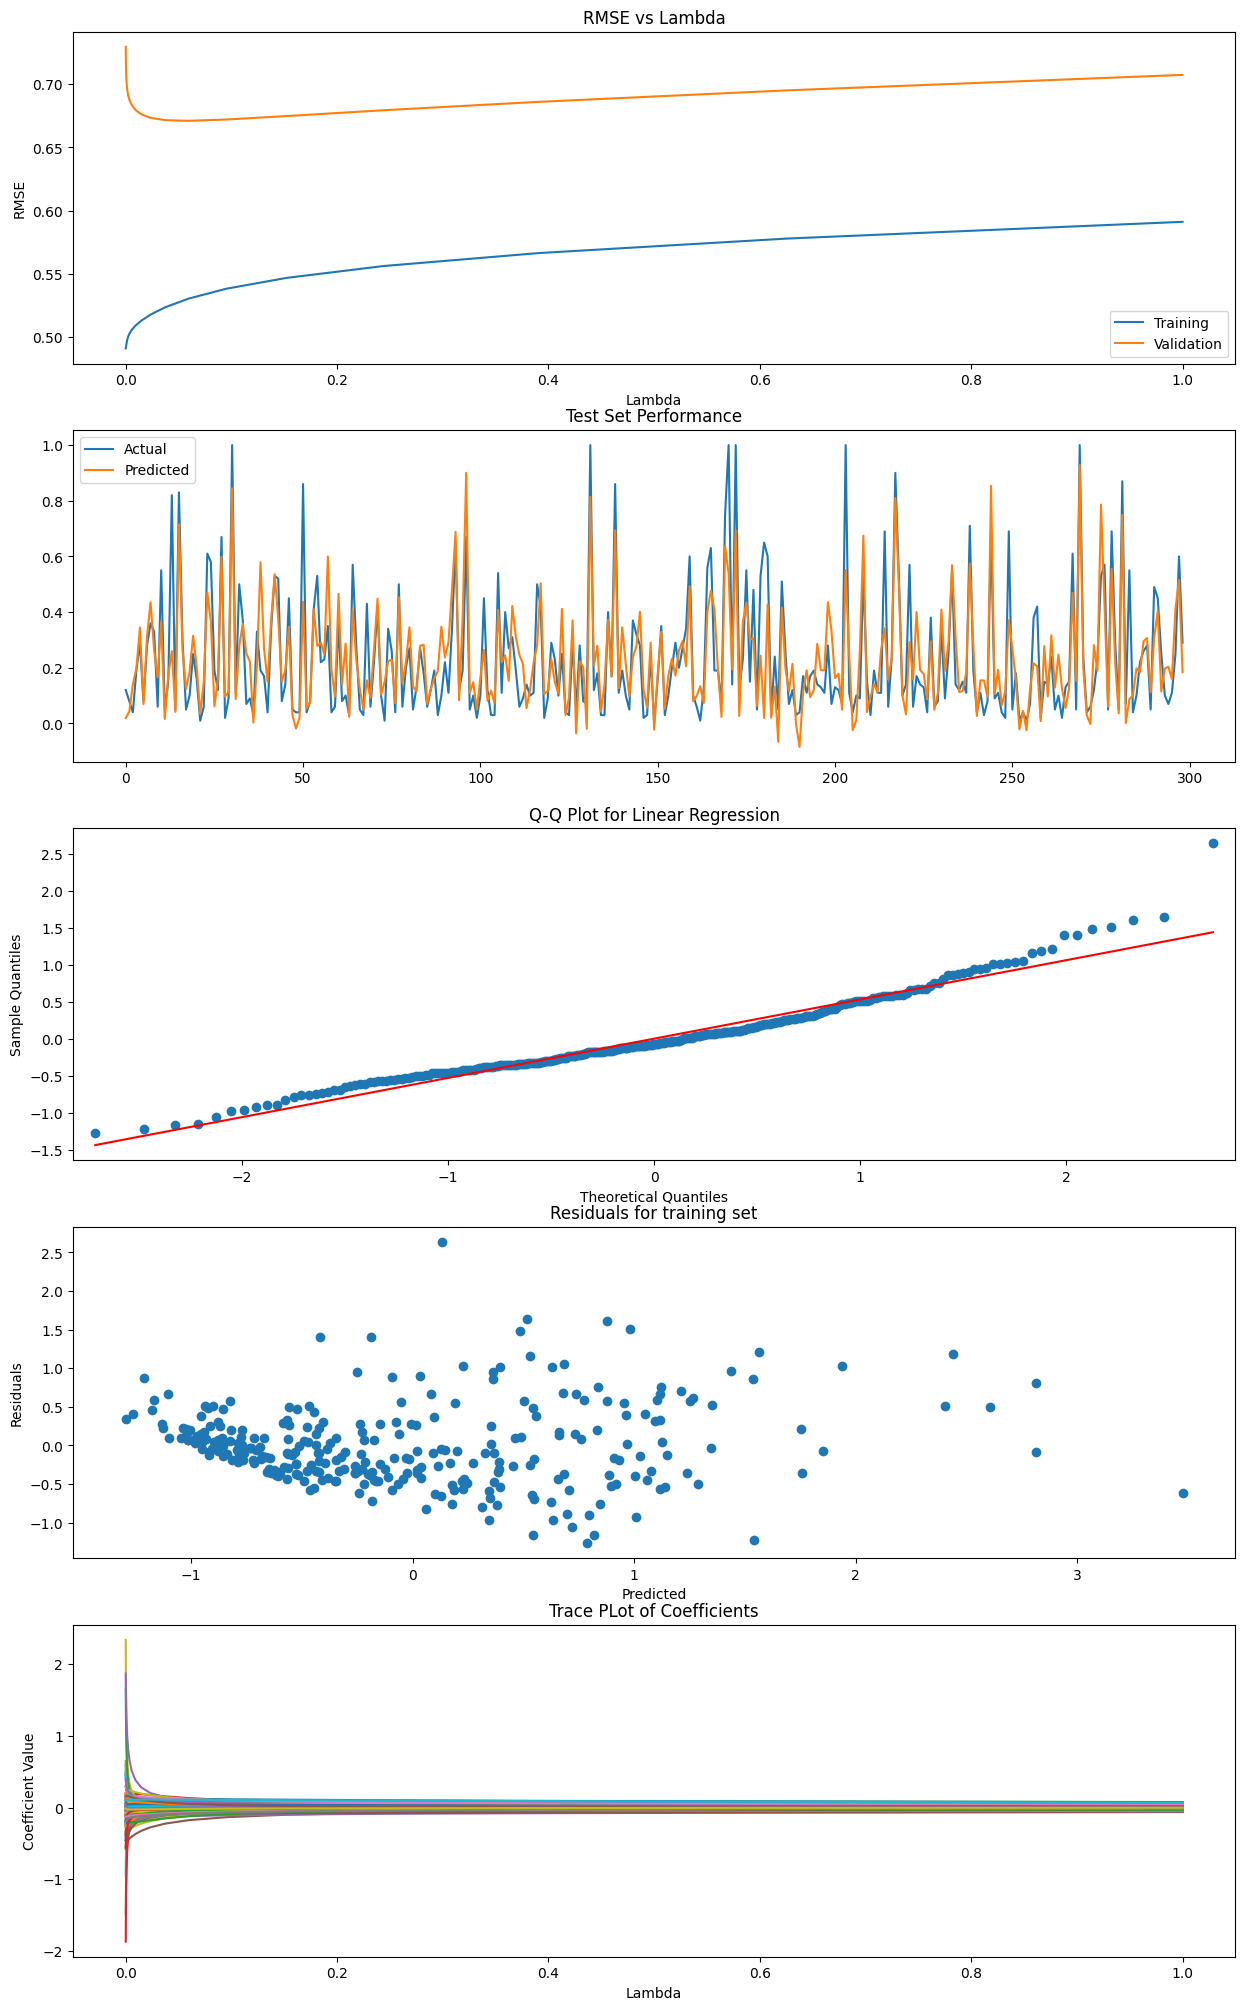

In [6]:
def rmse(actual, pred):
  return np.sqrt(mean_squared_error(actual, pred))

def r_squared(actual, predicted):
  r2 = r2_score(actual, predicted)
  return r2

def adj_r2(actual, predicted, n, p):
  r2 = r2_score(actual, predicted)
  adjr2 = 1 - (1 - r2) * (n - 1) / (n - p - 1);
  return adjr2

def evaluate_regularisation(x_train, y_train, x_val, y_val, x_test, y_test,
                            response_mu, response_sigma, alpha_list, L1_L2):
  """
  Evaluates the efficacy of regularisation for a linear model.
  
  Identifies which values regression coffections and values of alpha
  (the hyperparam for the strength of regularisation) offers the
  best performance on the validation set.

  Evaluation is required to be performed on the standardised data, to allow
  for ease of comparison (where standardised here refers to normalisation,
  such that the data has a mean of zero and a std. of one.) This will show
  
  Will display the coefficients used in the NORMALISED/STANDARDISED model 
  used to achieve the best results.

  Is able to evaluate both Ridge and Lasso regularisation (and Elasticnet
  really if you want to try it, but in this class we are sticking to Ridge
  and Lasso).

  Args:
    x_train (np.array):
      normalised predictor variable training data
    y_train (np.array):
      normalised response variable training data
    x_val (np.array):
      normalised predictor variable validation data
    y_val (np.array):
      normalised response variable validation data
    x_test (np.array):
      normalised predictor variable test data
    y_test (np.array):
      normalised response variable test data
    response_mu (np.array):
      the mean value of the response variable from the TRAINING data
    response_sigma (np.array):
      the standard deviation  of the response variable from the TRAINING data
    alpha_list (list[np.float]):
      proposed values for alpha (the regularisation hyper param, also called
      lambda in other texts and in the lectures). Each value must be greater
      than zero.
    L1_L2 (np.int):
      Boolean to say whether we want to perform Ridge or Lasso regularisation.
      When zero, will be Ridge, When one, will be Lasso.
      Note: this value can actually be a float between zero and one as well 
      if you want to try Elasticnet regression, but here in this class would
      recommend sticking to just Ridge and Lasso.

  Retuns:
    NA
  """
  # Ridge: L1_L2 = 0
  # Lasso: L1_L2 = 1
  # create the model
  model = sm.OLS(y_train, x_train)
  # initialise the value for best RMSE that is obnoxiously large, as we want this be 
  # overwritten each time RMSE is smaller, since smaller is better and we want to 
  # update our best models each time the RMSE is smaller.
  best_rmse = 10e12
  best_alpha = []
  best_coeffs = []
  
  rmse_val = []
  rmse_train = []
  coeffs = []          # only needed for trace plots

  for alpha in alpha_list:
    model_cross_fit = model.fit_regularized(alpha=alpha, L1_wt=L1_L2)
    train_pred = model_cross_fit.predict(x_train)
    val_pred = model_cross_fit.predict(x_val)
    # want to append the rmse value to a list, as will plot all values later on
    rmse_train.append(np.sqrt(mean_squared_error(y_train, train_pred)))
    rmse_val.append(np.sqrt(mean_squared_error(y_val, val_pred)))
    coeffs.append(model_cross_fit.params)
    # if this is the model with the lowest RMSE, lets save it
    # the [-1] index says get the last value from the list (which is the most recent RMSE)
    if rmse_val[-1] < best_rmse:
      best_rmse = rmse_val[-1]
      best_alpha = alpha
      best_coeffs = model_cross_fit.params
      
  print('Best values on Validation Data set')
  print('Best Lambda (Alpha) = {}'.format(best_alpha))
  # extract the gradient and the bias from the coefficients
  # The reshape will make sure the slope is a column vector
  slope = np.array(best_coeffs[0:]).reshape(-1, 1)
  # the intercept coefficient is the last index variable, which was included with the
  # sm.add_constant() method
  # use the @ operator to perform vector/matrix multiplication
  pred_val_rescaled = (x_val @ slope) * response_sigma + response_mu
  pred_test_rescaled = (x_test @ slope) * response_sigma + response_mu
  pred_train_rescaled = (x_train @ slope) * response_sigma + response_mu
  best_r2 = r_squared(y_train * response_sigma + response_mu, pred_train_rescaled)
  best_adj_r2 = adj_r2(y_train * response_sigma + response_mu, pred_train_rescaled,
                           x_train.shape[0], x_train.shape[1]) 
  best_val_rmse = np.sqrt(mean_squared_error(y_val* response_sigma + response_mu, pred_val_rescaled))
  best_test_rmse = np.sqrt(mean_squared_error(y_test* response_sigma + response_mu, pred_test_rescaled))
  print('Best R Squared = {}'.format(best_r2))
  print('Best Adjusted = {}'.format(best_adj_r2))
  print('Best RMSE (val) = {}'.format(best_val_rmse))
  print('Best RMSE (test) = {}'.format(best_test_rmse))
  print('Best coefficients on the normalised model')
  print('Best slope = {}'.format(slope))
  
  # now plotting some data
  fig, axs = plt.subplots(5, figsize=(15, 25))
  
  # plot the first values of alpha vs RMSE for train and validation data    
  axs[0].plot(np.array(alpha_list), rmse_train)
  axs[0].plot(np.array(alpha_list), rmse_val)
  axs[0].legend(['Training', 'Validation'])
  axs[0].set_title('RMSE vs Lambda')
  axs[0].set_xlabel('Lambda')
  axs[0].set_ylabel('RMSE')    
  
  # plot prediction and true values for test set
  axs[1].plot((y_test*response_sigma + response_mu))
  axs[1].plot((x_test @ slope) * response_sigma + response_mu)
  axs[1].legend(['Actual', 'Predicted'])
  axs[1].set_title('Test Set Performance')
  
  # plotting the Q-Q plot
  train_pred = (x_train @ slope).reshape(y_train.shape)
  resid = y_train - train_pred
  sm.qqplot(resid, ax=axs[2], line='s')
  axs[2].set_title('Q-Q Plot for Linear Regression')

  # plot the residuals as well
  axs[3].scatter(train_pred, resid)
  axs[3].set_title('Residuals for training set')
  axs[3].set_xlabel('Predicted')
  axs[3].set_ylabel('Residuals')

  # trace plot of coefficients
  axs[4].plot(np.array(alpha_list), coeffs)
  axs[4].set_title('Trace PLot of Coefficients')
  axs[4].set_xlabel('Lambda')
  axs[4].set_ylabel('Coefficient Value') 

## Evaluating Ridge regression
evaluate_regularisation(X_train_std, Y_train_std, X_val_std, Y_val_std, X_test_std, Y_test_std,
                        mu_train_y, sigma_train_y, alphas, 0)


Best values on Validation Data set
Best Lambda (Alpha) = 0.0022229964825261957
Best R Squared = 0.7061988543229842
Best Adjusted = 0.5570612169234839
Best RMSE (val) = 0.14389463825493057
Best RMSE (test) = 0.1319767715319294
Best coefficients on the normalised model
Best slope = [[ 0.09204591]
 [ 0.        ]
 [ 0.12630045]
 [-0.03146438]
 [ 0.        ]
 [ 0.        ]
 [-0.06472499]
 [ 0.10180273]
 [ 0.        ]
 [ 0.08804755]
 [ 0.        ]
 [ 0.07890573]
 [ 0.06265501]
 [-0.02780383]
 [ 0.        ]
 [-0.07793692]
 [ 0.        ]
 [ 0.        ]
 [-0.11334777]
 [-0.0430436 ]
 [ 0.        ]
 [ 0.        ]
 [-0.02282061]
 [-0.03895612]
 [ 0.10826013]
 [ 0.01005435]
 [ 0.04870822]
 [ 0.        ]
 [-0.19216042]
 [ 0.        ]
 [ 0.01359931]
 [ 0.00712833]
 [-0.10790635]
 [ 0.14888872]
 [-0.07809367]
 [ 0.        ]
 [ 0.        ]
 [-0.0757814 ]
 [-0.06233277]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [-0.31796367]
 [ 0.        ]
 [-0.10916834]
 [ 0.        ]
 [ 0.        ]

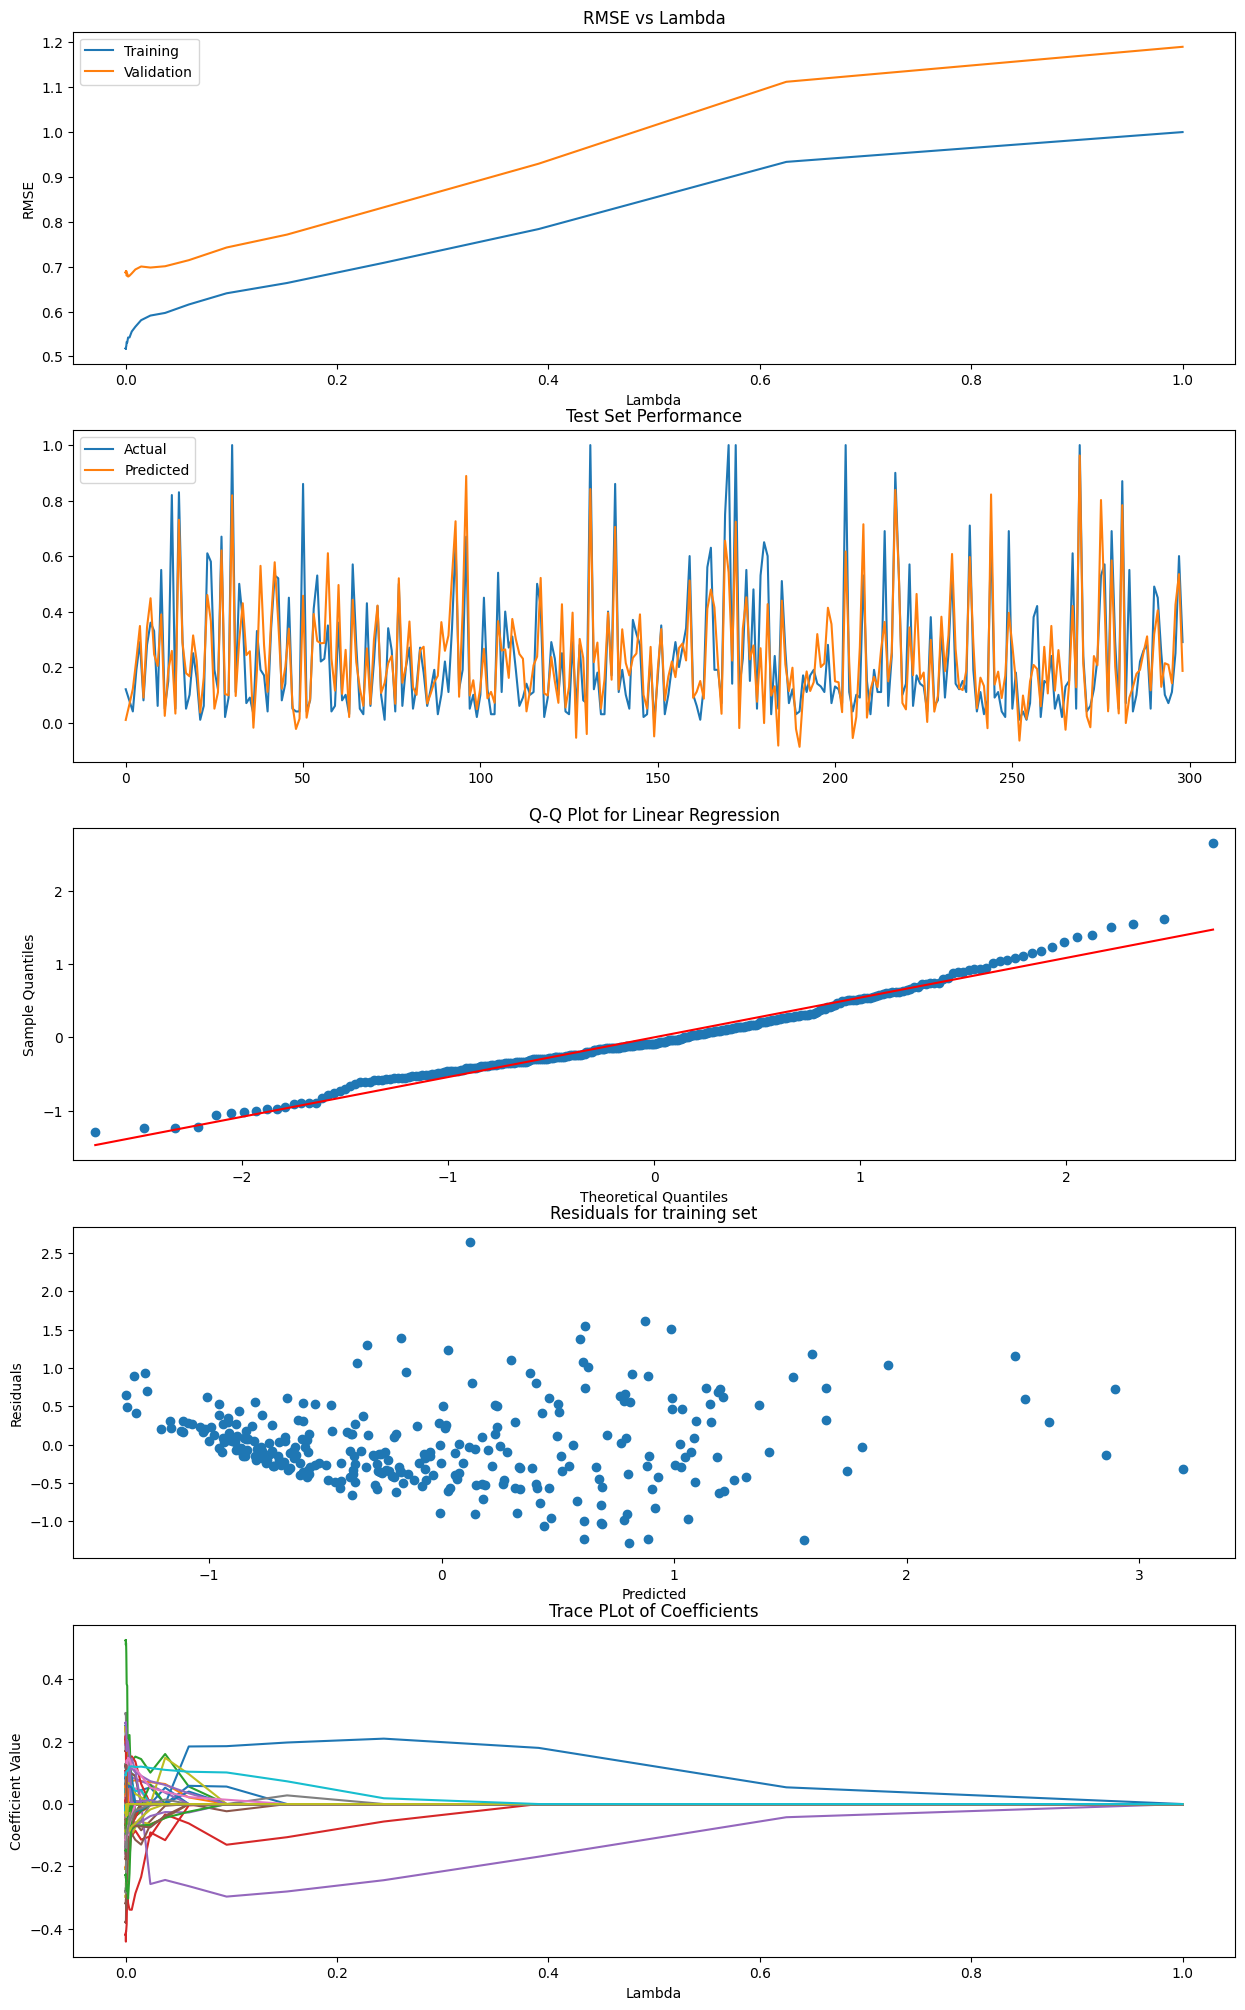

In [7]:
# Evaluating Lasso
evaluate_regularisation(X_train_std, Y_train_std, X_val_std, Y_val_std, X_test_std, Y_test_std,
                        mu_train_y, sigma_train_y, alphas, 1)

In [8]:
# For your write-up, you should include:
# - a discussion of any pre-processing you did and why; or why you left the data as-is
# - a discussion of how you selected the values of lambda used in your regularised models, and what those values are
# - a comparison of three models, considering both the accuracy and validity of the models, as outlined above, this means:
#   > accuracy of the model
#   > measures of fit, such as R^2
#   > testing assumptions about the independence of predictors, and the distribution of the residuals
# - A discussion of the ethical concerns that need to be considered when evaluating the models developed for this problem
# Your write-up should be supported by appropriate figures and tables. Figures and tables should have numbers and meaningful captions. 
# Note that figures and tables are not included in the page limits.
#
# SEE THE ASSIGNMENT BRIEF ON CANVAS FOR MORE DETAILS AND NOTE THAT A NOTEBOOK FILE DOES NOT CONSTITUTE A VALID SUBMISSION. 
# YOU SHOULD WRITE UP YOUR RESPONSE IN A SEPARATE DOCUMENT

In [10]:
# 1. Re-fit the Lasso model using the best alpha you found
# (Replace 'best_alpha_lasso' with the actual best lambda value printed from your previous cell)
best_alpha_lasso = 0.0022229964825261957 # Example value, update this!
lasso_model = sm.OLS(Y_train_std, X_train_std).fit_regularized(alpha=best_alpha_lasso, L1_wt=1)

# 2. Get the feature names from your original 'train' dataframe 
# We use [:-1] to exclude the final target variable ('ViolentCrimesPerPop')
feature_names = train.columns[:-1]

# 3. Create a pandas DataFrame to match features with their new coefficients
lasso_coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_model.params
})

# 4. Filter and display ONLY the features that were shrunk to exactly zero
eliminated_features = lasso_coefs[lasso_coefs['Coefficient'] == 0.0]

print(f"Lasso regularization completely eliminated {len(eliminated_features)} features:")
print("-" * 50)
print(eliminated_features)

Lasso regularization completely eliminated 44 features:
--------------------------------------------------
                   Feature  Coefficient
x2          householdsize           0.0
x5           racePctAsian           0.0
x6            racePctHisp           0.0
x9            agePct16t24           0.0
x11             numbUrban           0.0
x15          pctWFarmSelf           0.0
x17            pctWSocSec           0.0
x18           pctWPubAsst           0.0
x21             perCapInc           0.0
x22           whitePerCap           0.0
x28           NumUnderPov           0.0
x30       PctLess9thGrade           0.0
x36       PctEmplProfServ           0.0
x37          PctOccupManu           0.0
x40        MalePctNevMarr           0.0
x41          FemalePctDiv           0.0
x42           TotalPctDiv           0.0
x43            PersPerFam           0.0
x45           PctKids2Par           0.0
x47           PctTeen2Par           0.0
x48   PctWorkMomYoungKids           0.0
x50          